In [1]:
import sys
!{sys.executable} -m pip install cartopy cmocean xroms cartopy matplotlib geopy seawater pandas shapely scipy astropy statsmodels 

In [2]:
!{sys.executable} -m pip install xarray scikit-learn

In [3]:
import numpy as np
import netCDF4 as nc
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import patches
from matplotlib.collections import PatchCollection
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap
#from cmocean import cm
from datetime import date, datetime, timedelta
import datetime
import geopy
import geopy.distance
import seawater as sw
from mpl_toolkits.mplot3d import Axes3D
# import pyroms
# import pyroms_toolbox
# from pyroms.hgrid import *
# from pyroms.vgrid import *
# from pyroms.grid import *
# from pyroms import io
import pandas as pd 
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from scipy.signal import find_peaks,medfilt, detrend, butter, filtfilt
import scipy.signal as signal
from scipy.stats import linregress,pearsonr
from scipy.interpolate import griddata
import scipy.io as sio
from scipy import stats
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from astropy.convolution import Box1DKernel,Box2DKernel,convolve
import calendar
from statsmodels.tsa.seasonal import STL
from sklearn.linear_model import LinearRegression
from collections import OrderedDict, defaultdict

# outpath = '/user/yiming.guo/analysis_figures/NES_Downscaling/Figures_analysis/'

# def get_polygon_mask(polygon,lon,lat):
#     ###lat, lon 2d arrays
#     mask = np.nan*np.zeros(lat.shape)
#     for j in range(lat.shape[0]):
#         for i in range(lat.shape[1]):
#             point = Point(lon[j,i],lat[j,i])
#             if point.within(polygon)==True:
#                 mask[j,i] = 1;
#     return mask

FY = np.arange(1,9,1); #tau
Start_years = np.arange(1992,2012,1); #i:1-N
ensembles = np.arange(1,11,1); nfiles = np.arange(1,13,1);

/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41764/1995992629.py:23: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [4]:
romsdata = nc.Dataset('/Users/sydneyperkins/Downloads/ROMS_Downscaling_temp_cold_pool_SY1992_SY2011_LY1_8 1.nc','r')
glorysdata = nc.Dataset('/Users/sydneyperkins/Downloads/GLORYS_temp_cold_pool_1993_2019 1.nc','r')

In [5]:
def get_polygon_mask(polygon,lon,lat):
    ###lat, lon 2d arrays
    mask = np.nan*np.zeros(lat.shape)
    for j in range(lat.shape[0]):
        for i in range(lat.shape[1]):
            point = Point(lon[j,i],lat[j,i])
            if point.within(polygon)==True:
                mask[j,i] = 1;
ColdPool_coords = [(-74.8,35.5),(-75.4,35.7),(-75.8,36.97),(-74,39.6),(-73.8,40.4)
                   ,(-71.6,41.0),(-71.0,41.4),(-70.38,41.2),(-69.68,41.05)
                   ,(-69.2,40.05),(-69.67,39.95),(-71.4,39.9),(-72,39.7),(-73.8,38.0),(-74.6,37)]
ColdPool_polygon = Polygon(ColdPool_coords)



In [5]:
year1 = 2004; year2 = 2009; nyears = year2-year1;

coldpool_glorys = glorysdata.variables['temp_cold_pool'][year1-1993:year2-1993,:,:,:]
coldpool0_glorys = glorysdata.variables['temp_cold_pool'][:,:,:,:]

lat_glorys = glorysdata.variables['lat'][:]
lon_glorys = glorysdata.variables['lon'][:]
#glorysdata.close();

coldpool_roms = np.nanmean(romsdata.variables['temp_cold_pool'][year1-1992,:,0:nyears,:,:,:],axis=0)
coldpool_roms_ens = romsdata.variables['temp_cold_pool'][year1-1992,:,0:nyears,:,:,:]

#coldpool_roms = np.nanmean(romsdata.variables['temp_cold_pool'][:,:,:,:,:,:],axis=0)
lat_roms = romsdata.variables['lat_roms'][:]
lon_roms = romsdata.variables['lon_roms'][:]
#romsdata.close();


/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41387/3345269840.py:10: RuntimeWarning: Mean of empty slice
  coldpool_roms = np.nanmean(romsdata.variables['temp_cold_pool'][year1-1992,:,0:nyears,:,:,:],axis=0)


In [13]:
sources = ['glorys','roms']
source_names = ['GLORYS','ROMS-DOWN']
clev = np.linspace(7,10,12)
fig = plt.figure(figsize=(30,8)); fs=15;
#Enumerate adds indexes to the values. the index is s and the value is under variable sour
for s,sour in enumerate(sources):
    for yr in range(nyears):
        m=fig.add_subplot(2,nyears,s*nyears+yr+1,projection=ccrs.PlateCarree(central_longitude=-180))
        cont = m.contourf(vars()['lon_'+sour],vars()['lat_'+sour],np.nanmean(vars()['coldpool_'+sour][yr,:,:,:],
                            axis=0),levels=clev,extend='both',transform = ccrs.PlateCarree());
        cbar=plt.colorbar(cont);cbar.set_ticks(np.arange(7,10.5,0.5));
        m.coastlines();m.set_aspect('auto', adjustable=None)
        m.set_xticks(np.arange(284,315,2),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
        m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params();
        m.set_yticks(np.arange(32,52,2),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
        m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params();
        m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
        polygon_outline = patches.Polygon(ColdPool_coords,closed=True, edgecolor='r', linewidth=3,
                             facecolor='none',transform = ccrs.PlateCarree())
        m.add_patch(polygon_outline);
        plt.title(source_names[s]+'-'+str(yr+year1),fontsize=fs)

/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/2090936669.py:9: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_'+sour],vars()['lat_'+sour],np.nanmean(vars()['coldpool_'+sour][yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/2090936669.py:9: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_'+sour],vars()['lat_'+sour],np.nanmean(vars()['coldpool_'+sour][yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/2090936669.py:9: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_'+sour],vars()['lat_'+sour],np.nanmean(vars()['coldpool_'+sour][yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/2090936669.py:9: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_'+sour],vars()['lat_'+sour],np.nanmean(vars()['coldpool_'+sour][yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/2090936669.py:9: RuntimeWarning: Me

Error in callback <function _draw_all_if_interactive at 0x14c3e2660> (for post_execute), with arguments args (),kwargs {}:


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

<Figure size 3000x800 with 20 Axes>

In [8]:
clev = np.linspace(7,10,12)
fig = plt.figure(figsize=(30,8)); fs=15;
name1= ['GLORYS']

for yr in range(nyears):
        m=fig.add_subplot(2,nyears,s*nyears+yr+1,projection=ccrs.PlateCarree(central_longitude=-180))
        cont = m.contourf(vars()['lon_glorys'],vars()['lat_glorys'],np.nanmean(vars()['coldpool_glorys'][yr,:,:,:],
                            axis=0),levels=clev,extend='both',transform = ccrs.PlateCarree());
        cbar=plt.colorbar(cont);cbar.set_ticks(np.arange(7,10.5,0.5));
        m.coastlines();m.set_aspect('auto', adjustable=None)
        m.set_xticks(np.arange(284,315,2),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
        m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params();
        m.set_yticks(np.arange(32,52,2),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
        m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params();
        m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
        polygon_outline = patches.Polygon(ColdPool_coords,closed=True, edgecolor='r', linewidth=3,
                             facecolor='none',transform = ccrs.PlateCarree())
        m.add_patch(polygon_outline);
        plt.title(f"{"GLORYS"} {'-'+str(yr+year1)}", fontsize=fs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Error in callback <function _draw_all_if_interactive at 0x14c3e2660> (for post_execute), with arguments args (),kwargs {}:


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

<Figure size 3000x800 with 10 Axes>

In [9]:
clev = np.linspace(7,10,12)
fig = plt.figure(figsize=(30,8)); fs=15;
name1= ['GLORYS']

for yr in range(nyears):
        m=fig.add_subplot(2,nyears,s*nyears+yr+1,projection=ccrs.PlateCarree(central_longitude=-180))
        cont = m.contourf(vars()['lon_glorys'],vars()['lat_glorys'],np.nanmean(vars()['coldpool_glorys'][yr,:,:,:],
                            axis=0),levels=clev,extend='both',transform = ccrs.PlateCarree());
        cbar=plt.colorbar(cont);cbar.set_ticks(np.arange(7,10.5,0.5));
        m.coastlines();m.set_aspect('auto', adjustable=None)
        m.set_xticks(np.arange(284,315,2),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
        m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params();
        m.set_yticks(np.arange(32,52,2),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
        m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params();
        m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
        polygon_outline = patches.Polygon(ColdPool_coords,closed=True, edgecolor='r', linewidth=3,
                             facecolor='none',transform = ccrs.PlateCarree())
        m.add_patch(polygon_outline);
        plt.title(f"{"GLORYS"} {'-'+str(yr+year1)}", fontsize=fs)



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Error in callback <function _draw_all_if_interactive at 0x14c3e2660> (for post_execute), with arguments args (),kwargs {}:


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

<Figure size 3000x800 with 10 Axes>

In [10]:
clev = np.linspace(7,10,12)
fig = plt.figure(figsize=(30,8)); fs=15;
name1= ['GLORYS']

for yr in range(nyears):
        m=fig.add_subplot(2,nyears,s*nyears+yr+1,projection=ccrs.PlateCarree(central_longitude=-180))
        cont = m.contourf(vars()['lon_glorys'],vars()['lat_glorys'],np.nanmean(vars()['coldpool_glorys'][yr,:,:,:],
                            axis=0),levels=clev,extend='both',transform = ccrs.PlateCarree());
        cbar=plt.colorbar(cont);cbar.set_ticks(np.arange(7,10.5,0.5));
        m.coastlines();m.set_aspect('auto', adjustable=None)
        m.set_xticks(np.arange(284,315,2),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
        m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params();
        m.set_yticks(np.arange(32,52,2),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
        m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params();
        m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
        polygon_outline = patches.Polygon(ColdPool_coords,closed=True, edgecolor='r', linewidth=3,
                             facecolor='none',transform = ccrs.PlateCarree())
        m.add_patch(polygon_outline);
        plt.title(f"{"GLORYS"} {'-'+str(yr+year1)}", fontsize=fs)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Error in callback <function _draw_all_if_interactive at 0x14c3e2660> (for post_execute), with arguments args (),kwargs {}:


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

<Figure size 3000x800 with 10 Axes>

In [11]:
fig = plt.figure(figsize=(30,8)); fs=15;
for yr in range(nyears):
    m=fig.add_subplot(2,nyears,s*nyears+yr+1,projection=ccrs.PlateCarree(central_longitude=-180))
    cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][:,yr,:,:,:],
                        axis=(0,1)),levels=clev,extend='both',transform = ccrs.PlateCarree());
    cbar=plt.colorbar(cont);cbar.set_ticks(np.arange(7,10.5,0.5));
    m.coastlines();m.set_aspect('auto', adjustable=None)
    m.set_xticks(np.arange(284,315,2),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
    m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params();
    m.set_yticks(np.arange(32,52,2),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
    m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params();
    m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
    polygon_outline = patches.Polygon(ColdPool_coords,closed=True, edgecolor='r', linewidth=3,
                         facecolor='none',transform = ccrs.PlateCarree())
    m.add_patch(polygon_outline);
    plt.title(f"{"ROMS"} {'-'+str(yr+year1)}", fontsize=fs)


/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/3477353810.py:4: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][:,yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/3477353810.py:4: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][:,yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/3477353810.py:4: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][:,yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/3477353810.py:4: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][:,yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/3477353810.py:4: Runtim

Error in callback <function _draw_all_if_interactive at 0x14c3e2660> (for post_execute), with arguments args (),kwargs {}:


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

<Figure size 3000x800 with 10 Axes>

In [12]:
ensemble = 10
fig = plt.figure(figsize=(50,25)); fs=15;
for yr in range(nyears):
  for ens in range(ensemble):
    m=fig.add_subplot(nyears,ensemble,yr*ensemble+ens+1,projection=ccrs.PlateCarree(central_longitude=-180))
    cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][ens,yr,:,:,:],
                        axis=(0)),levels=clev,extend='both',transform = ccrs.PlateCarree());
    cbar=plt.colorbar(cont);cbar.set_ticks(np.arange(7,10.5,0.5));
    m.coastlines();m.set_aspect('auto', adjustable=None)
    m.set_xticks(np.arange(284,315,2),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
    m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params();
    m.set_yticks(np.arange(32,52,2),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
    m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params();
    m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
    polygon_outline = patches.Polygon(ColdPool_coords,closed=True, edgecolor='r', linewidth=3,
                         facecolor='none',transform = ccrs.PlateCarree())
    m.add_patch(polygon_outline);
    if yr == 0:
            m.set_title(ens, fontsize=10, pad= 10, va='center')

        # Label the first column
    if ens == 0:
            m.set_ylabel(yr+year1, rotation=0, labelpad=15, fontsize=10)
    plt.title(f"{"ROMS"+str(ens+1)}", fontsize=fs)
plt.show()
fig.savefig("ROMS_2004_2009_allens.png", dpi=300, bbox_inches='tight')
files.download('ROMS_2004_2009_allens.png')


/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/13352187.py:6: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][ens,yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/13352187.py:6: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][ens,yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/13352187.py:6: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][ens,yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/13352187.py:6: RuntimeWarning: Mean of empty slice
  cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms_ens'][ens,yr,:,:,:],
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/13352187.py:6: RuntimeW

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

<Figure size 5000x2500 with 100 Axes>

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

In [ ]:
year1 = 1995; nyears= 8
coldpool_roms = np.nanmean(romsdata.variables['temp_cold_pool'][year1-1992,:,0:nyears,:,:,:],axis=0)
coldpool_roms_ens_1996 = romsdata.variables['temp_cold_pool'][year1-1992,:,0:nyears,:,:,:]
ensemble = 10
fig = plt.figure(figsize=(50,25)); fs=15;
for yr in range(nyears):
    m=fig.add_subplot(nyears,ensemble,yr*ensemble+ens+1,projection=ccrs.PlateCarree(central_longitude=-180))
    cont = m.contourf(vars()['lon_roms'],vars()['lat_roms'],np.nanmean(vars()['coldpool_roms'][yr,:,:,:],
                        axis=(0)),levels=clev,extend='both',transform = ccrs.PlateCarree());
    cbar=plt.colorbar(cont);cbar.set_ticks(np.arange(7,10.5,0.5));
    m.coastlines();m.set_aspect('auto', adjustable=None)
    m.set_xticks(np.arange(284,315,2),crs=ccrs.PlateCarree()); lon_formatter = cticker.LongitudeFormatter();
    m.xaxis.set_major_formatter(lon_formatter); m.xaxis.set_tick_params();
    m.set_yticks(np.arange(32,52,2),crs=ccrs.PlateCarree()); lat_formatter = cticker.LatitudeFormatter();
    m.yaxis.set_major_formatter(lat_formatter); m.yaxis.set_tick_params();
    m.set_extent([-77,-65,35,45],crs=ccrs.PlateCarree());
    polygon_outline = patches.Polygon(ColdPool_coords,closed=True, edgecolor='r', linewidth=3,
                         facecolor='none',transform = ccrs.PlateCarree())
    m.add_patch(polygon_outline);
    plt.title(f"{"ROMS"+str(year1+yr)}", fontsize=fs)
plt.show()

In [14]:
year1 = 2004; year2 = 2012; nyears = year2-year1;
lat_glorys = glorysdata.variables['lat'][:]
lon_glorys = glorysdata.variables['lon'][:]
z_glorys = glorysdata.variables['depth'][:]
R = 6371000 # Earth's radius in meters
lat_rad_g = np.radians(lat_glorys)
lon_rad_g = np.radians(lon_glorys)

dlat_g = np.diff(lat_rad_g)
dy_g = R * dlat_g #arc length (distance) of the different lat points
dy_full_g = np.append(dy_g, dy_g[-1]) #matching grid size
dx_g = np.zeros((len(lat_glorys), len(lon_glorys)-1)) #pretty sure this just preps the variable to be filled in loop
for j, lat in enumerate(lat_rad_g):
    dlon = np.diff(lon_rad_g)
    dx_g[j, :] = R * np.cos(lat) * dlon
#j is the index lat is the value, difference in longitude is dlong
# dx at index j, all (:) columns is R*cos(lat)*dlon; arc length in long direction (?)
dx_full_g = np.pad(dx_g, ((0,0), (0,1)), mode='edge')  # pad to match grid size adds a column to the end
dz_g = np.diff(z_glorys)
dz_g = np.append(dz_g, dz_g[-1])  # shape: (depth,)

dx_2d_g, dy_2d_g = np.meshgrid(dx_full_g[0], dy_full_g)
area_g = dx_2d_g * dy_2d_g  # shape: [lat, lon]
volume_glorys = dz_g[:, np.newaxis, np.newaxis] * area_g[np.newaxis, :, :]/1e9
coldpool_glorys = glorysdata.variables['temp_cold_pool'][:,:,:,:]#year,depth,lat,lon
cp_vol_glorys = np.zeros((coldpool_glorys.shape[0]))
for yr in range(coldpool_glorys.shape[0]):
    temp = coldpool_glorys[yr,:,:,:]
    temp[np.where(np.isnan(temp)==0)] = 1;
    cp_vol_glorys[yr] = np.nansum(temp*volume_glorys)
cp_temp_glorys = np.nanmean(glorysdata.variables['temp_cold_pool'][:,:,:,:],axis=(1,2,3))#year,depth,lat,lon

In [15]:
FY = np.arange(1,9,1); #tau
Start_years = np.arange(1992,2012,1); #i:1-N
ensembles = np.arange(1,11,1); nfiles = np.arange(1,13,1);

In [16]:
lat_roms = romsdata.variables['lat_roms'][:]
lon_roms = romsdata.variables['lon_roms'][:]
z_roms = romsdata.variables['roms_depth'][:]
lat_rad_r = np.radians(lat_roms)
lon_rad_r = np.radians(lon_roms)
nz, ny, nx = z_roms.shape
dy_r = np.zeros((ny,nx))
dx_r = np.zeros((ny,nx))
for j in range(0,ny):
  dy_r[j,:] = R * (lat_rad_r[j,:] - lat_rad_r[j-1,:])
dy_r[0, :] = dy_r[1, :]  # replicate first row
for i in range(0,nx):
  dx_r[:,i] = R * np.cos(lat_rad_r[:, i]) * (lon_rad_r[:, i] - lon_rad_r[:, i - 1])
dx_r[:, 0] = dx_r[:, 1]  # replicate first column
year1 = 2004; year2 = 2012; nyears = year2-year1;
dx_r = np.abs(dx_r)
dy_r = np.abs(dy_r)
area_r = dx_r * dy_r
dz_r = np.diff(z_roms, axis=0)  # shape: (z-1, lat, lon)
dz_last_r = dz_r[-1, :, :][np.newaxis, :, :]
dz_r = np.concatenate((dz_r, dz_last_r), axis=0) #stacks
volume_roms = abs(dz_r) * area_r[np.newaxis, :, :]/1e9  # shape: (z, lat, lon)
cp_vol_roms = np.zeros((len(Start_years),len(FY)))
for sy in range(len(Start_years)):
    for fy in range(len(FY)):
        temp = np.nanmean(romsdata.variables['temp_cold_pool'][sy,:,fy,:,:,:],axis=(0))#Start year,ens,FY,depth,lat,lon
        temp[np.where(np.isnan(temp)==0)] = 1;
        cp_vol_roms[sy,fy] = np.nansum(temp*volume_roms)

cp_temp_roms = np.zeros((len(Start_years),len(FY)))
for sy in range(len(Start_years)):
    for fy in range(len(FY)):
        data = romsdata.variables['temp_cold_pool'][sy,:,fy,:,:,:]
        data[data.mask] = np.nan
        cp_temp_roms[sy,fy] = np.nanmean(data)#Start year,ens,FY,depth,lat,lon


/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/3305230498.py:26: RuntimeWarning: Mean of empty slice
  temp = np.nanmean(romsdata.variables['temp_cold_pool'][sy,:,fy,:,:,:],axis=(0))#Start year,ens,FY,depth,lat,lon
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/3305230498.py:28: UserWarning: Warning: converting a masked element to nan.
  cp_vol_roms[sy,fy] = np.nansum(temp*volume_roms)
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/3305230498.py:35: RuntimeWarning: Mean of empty slice
  cp_temp_roms[sy,fy] = np.nanmean(data)#Start year,ens,FY,depth,lat,lon


In [ ]:
coldpool_glorys_mean = np.nanmean(glorysdata.variables['temp_cold_pool'][:,:,:,:], axis = (1,2,3))

<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_41173/2155679350.py:18: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Cold pool temperature [$^{\circ}$C]');


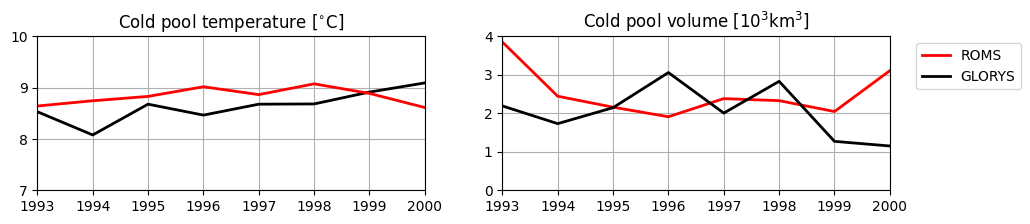

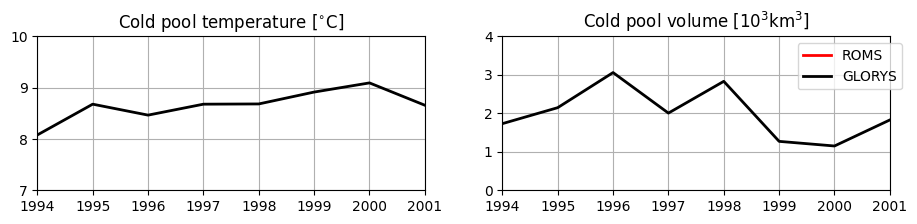

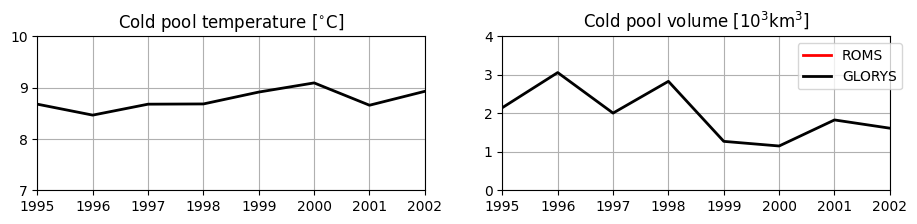

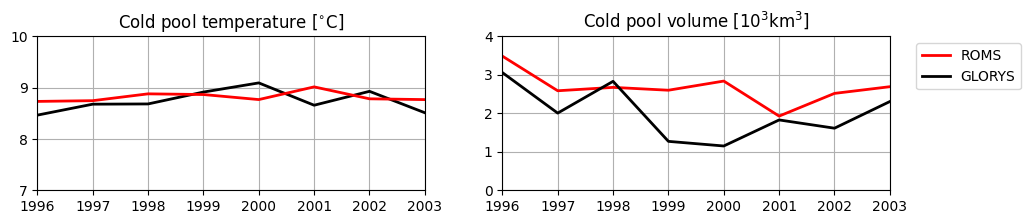

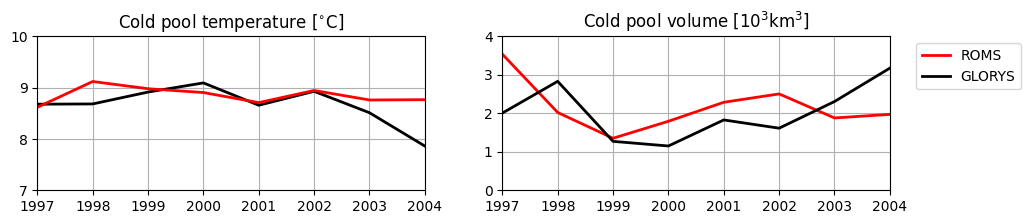

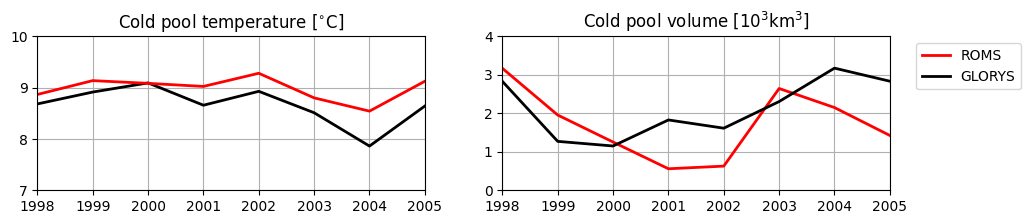

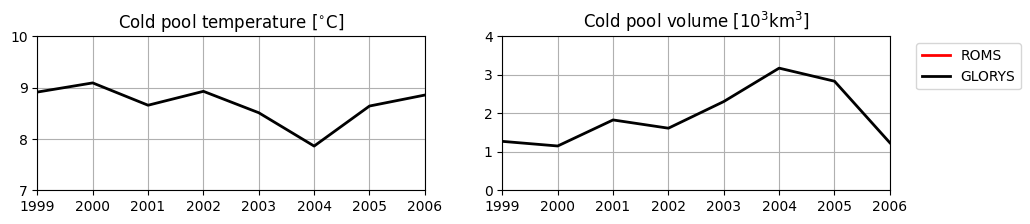

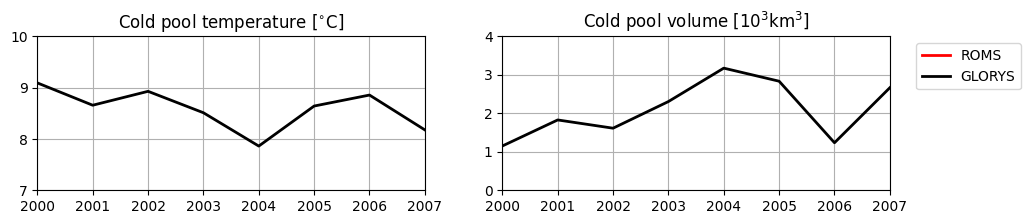

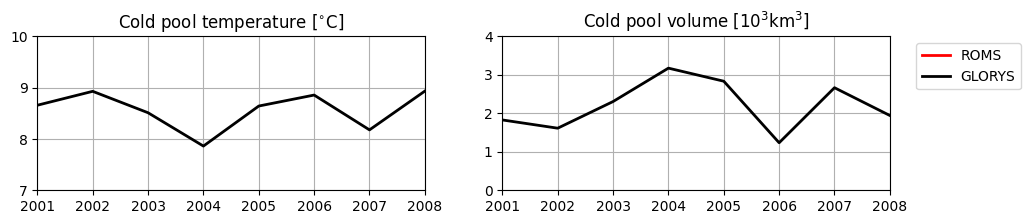

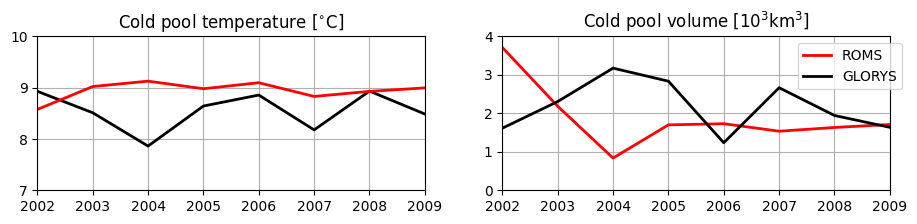

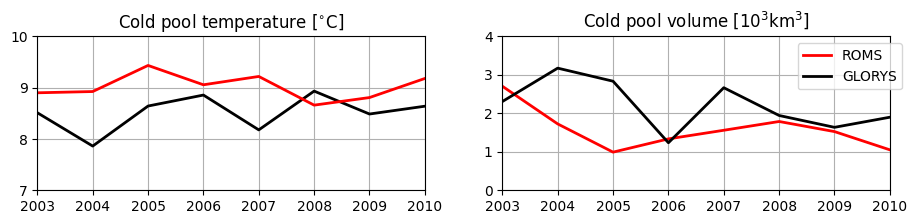

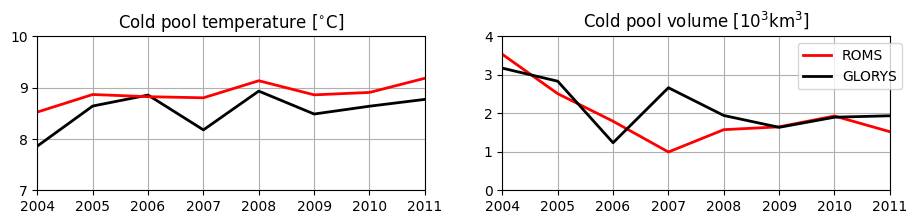

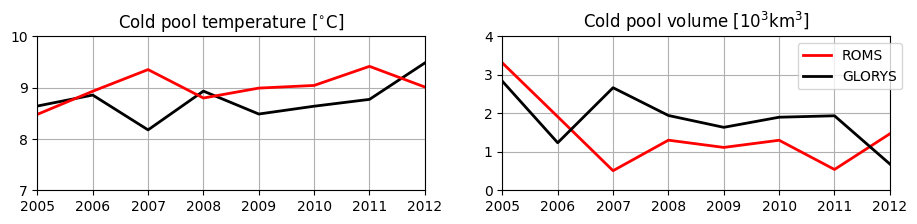

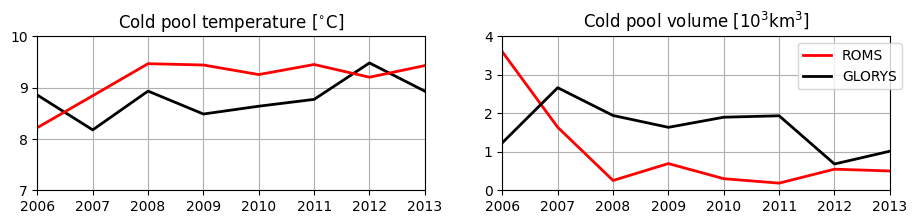

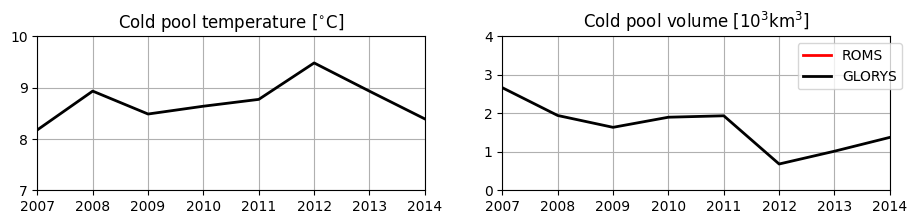

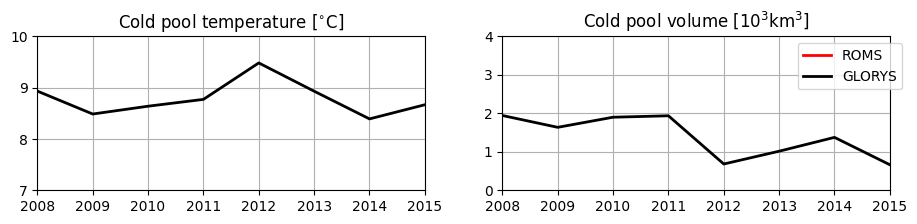

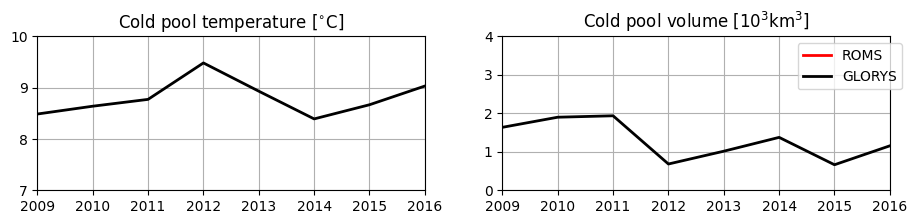

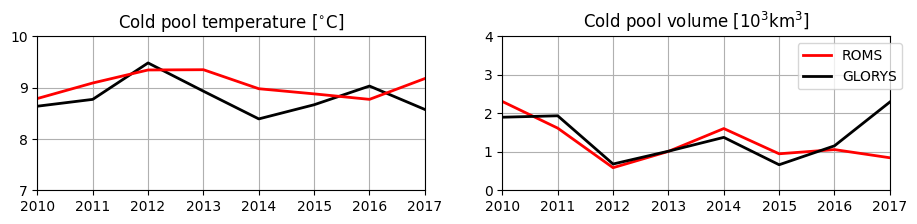

In [17]:
year1 = np.arange(1993,2011,1); year2= year1+8;
sources = ['glorys','roms'];
source_names = ['GLORYS','ROMS-DOWN']
colors = ['k','r']
#years = np.arange(year1, year2, dtype=int)
#year1 = np.arange(1993,2011,1);

for yr in (year1):
  year2= yr+8
  years = np.arange(yr, year2, dtype=int)
  plt.figure(figsize=(11,2)); lw=2;
  plt.subplot(1,2,1);
  datar = cp_temp_roms[yr-1992]
  datag = cp_temp_glorys[yr-1993:year2-1993]
  plt.plot(years,datag,color = 'k',linewidth=lw,label='GLORYS')
  plt.plot(years,datar,color = 'r',linewidth=lw,label='ROMS')
  plt.xticks(years)
  plt.title('Cold pool temperature [$^{\circ}$C]');
  plt.xlim(yr, year2-1);plt.ylim(7,10);
  plt.grid()


  plt.subplot(1,2,2);
  datar = cp_vol_roms[yr-1992]/1e3
  datag = cp_vol_glorys[yr-1993:year2-1993]/1e3
  plt.plot(years,datar,color = 'r',linewidth=lw,label='ROMS')
  plt.plot(years,datag,color = 'k',linewidth=lw,label='GLORYS')
  plt.xticks(years)
  plt.title('Cold pool volume [10$^{3}$km$^{3}$]');
  plt.xlim(yr,year2-1);plt.ylim(0,4);plt.legend(bbox_to_anchor=(1.05, 1.0));
  plt.grid()

In [ ]:
print(cp_temp_roms.shape)
#testing = np.nanmean(romsdata.variables['temp_cold_pool'][:,:,0,:,:,:], axis = (1,2,3,4))
print(testing.shape)
gtesting= np.nanmean(glorysdata.variables['temp_cold_pool'][0,:,:,:], axis = (1,2,3))
#testing2 = np.nanmean(romsdata.variables['temp_cold_pool'][:,:,1,:,:,:], axis = (1,3,4,5))

In [11]:
startyear = np.arange(0,20,1)
tempts = []
for yr in (startyear):
    temp_ts = np.nanmean(romsdata.variables['temp_cold_pool'][yr,:,:,:,:,:],axis=(0,2,3,4))#Start year,ens,FY,depth,lat,lon
    tempts.append(temp_ts)


(20, 8)


In [45]:
temp_glorys = np.nanmean(glorysdata.variables['temp_cold_pool'][:,:,:,:],axis=(1,2,3))
print(temp_ts.shape)
print(temp_glorys.shape)
print(years_ts.shape)

(8,)
(27,)
(27,)


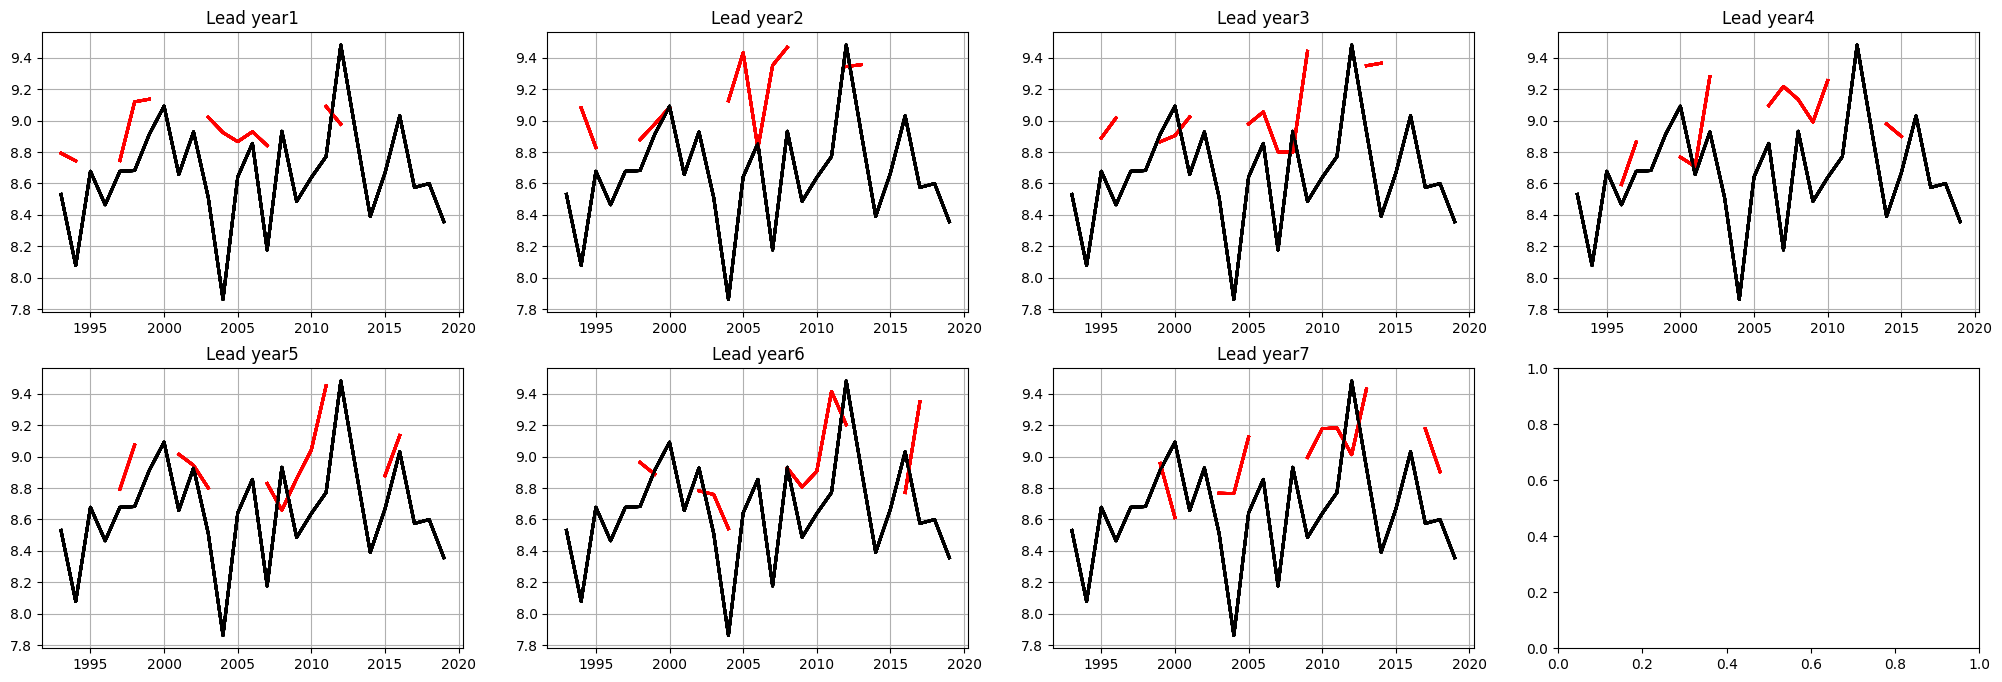

In [58]:
#roms_data_ts = romsdata.variables['temp_cold_pool'][0:19, :,:,:,:,:]
years = np.arange(1993,2020,1); start = np.arange(1,8,1); years_ts = np.arange(1993,2013,1)
fig, axes = plt.subplots(2, 4, figsize=(25, 8))  # 2 rows, 4 columns
axes = axes.flatten()

for i,fy in enumerate(start):
    ax = axes[i]
    for yr in (years_ts):
        tstemp = tempts[:,i+1]#Start year,ens,FY,depth,lat,lon
        #temp_glorys = np.nanmean(glorysdata.variables['temp_cold_pool'][yr-1993:yr-1993+27,:,:,:],axis=(0,1,2)) 
        ax.plot(years[i:20+i],tstemp,color = 'r',linewidth=lw,label='ROMS')
        ax.plot(years,temp_glorys,color = 'k',linewidth=lw,label='GLORYS')
        #plt.xticks(years_ts)
        ax.set_title('Lead year' +str(fy));
        #plt.xlim(yr, year2-1);plt.ylim(7,10);
        ax.grid(True)
    

